# DMD on a single wingbeat

> 2024-04-01 

The aim of this analysis is to find the dynamic modes of a single flapping wingbeat by hawks. 

The data contains 8 markers from hawks wings and tail during flight. The markers are tracked in 3D space and the data is collected at 200 Hz using motion capture. 

While the flights contain many flight behaviours, here we focus on a single wingbeat, the first after the take-off jump. The duration is around 0.2s. 

By finding the modes we hope to model the morphing dynamics of a bird wingbeat during flight in a reduced dimension space, which is easier for analysis and any bioinspired flapping design control.

## Loading Data

> 2024-04-03 
>
> 2024-04-19 

The data is saved as `npz` which contain numpy arrays. We will load the bilateral data, which means marker data is complete on both sides for every frame. 

In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from pydmd import DMD
from pydmd.bopdmd import BOPDMD
from pydmd.plotter import plot_eigs
from pydmd.plotter import plot_summary
from pydmd.preprocessing.hankel import hankel_preprocessing

from morphing_birds import Hawk3D, plot, interactive_plot, animate, animate_compare

from BirdDMD import plot_markers_overDist, plot_2d_markers, plot_single_sequence

np.set_printoptions(suppress=True, precision=3)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
column_names = np.load("../data/samples/ColumnNames.npz")
file = np.load("../data/samples/Initial_12mToothless_Bilateral.npz", allow_pickle=True)
marker_data = file["marker_data"]
info_data = file["info_data"]

marker_column_names = column_names["marker_column_names"]
info_column_names = column_names["info_column_names"]

# Create a pandas dataframe
marker_df = pd.DataFrame(marker_data, columns=marker_column_names)
info_df = pd.DataFrame(info_data, columns=info_column_names)

# Concatenate the dataframes vertically
wingbeat_df = pd.concat([info_df,marker_df], axis=1)

# Number of sequences
n_sequences = wingbeat_df["seqID"].nunique()
print("Number of sequences: ", n_sequences)

print(str(wingbeat_df.shape) + " dataframe loaded." )
wingbeat_df.head()

Number of sequences:  175
(3969, 37) dataframe loaded.


,frameID,seqID,time,HorzDistance,VertDistance,body_pitch,BirdID,PerchDistance,Year,Naive,...,left_secondary_z,right_secondary_x,right_secondary_y,right_secondary_z,left_tailtip_x,left_tailtip_y,left_tailtip_z,right_tailtip_x,right_tailtip_y,right_tailtip_z
0,04_12_101_001185,04_12_101,-0.03,11.499332,0.276187,2.393211,4,12,2017,1,...,-0.226782,0.169921,-0.095493,-0.211744,-0.168439,-0.236545,-0.067568,0.154861,-0.247628,-0.045616
1,04_12_101_001186,04_12_101,-0.025,11.481457,0.273949,3.144327,4,12,2017,1,...,-0.209808,0.155084,-0.090325,-0.196410,-0.164706,-0.240161,-0.070441,0.153624,-0.248515,-0.048600
2,04_12_101_001187,04_12_101,-0.02,11.463577,0.271129,3.549593,4,12,2017,1,...,-0.188957,0.145852,-0.084816,-0.176477,-0.161908,-0.243009,-0.071972,0.153762,-0.248931,-0.048551
3,04_12_101_001188,04_12_101,-0.015,11.445734,0.267755,3.633072,4,12,2017,1,...,-0.164022,0.140726,-0.080751,-0.151924,-0.158694,-0.245949,-0.072486,0.153036,-0.249604,-0.046252
4,04_12_101_001189,04_12_101,-0.01,11.42797,0.26386,3.474879,4,12,2017,1,...,-0.137684,0.134864,-0.076087,-0.125089,-0.154246,-0.249726,-0.072297,0.149444,-0.252392,-0.043923


## Average Shape of the Hawk

Within the data set there are 8 markers, which are used to represent the hawk's wing and tail. The markers are named as follows:

- Left Wingtip   (similar to the fingertip)
- Right Wingtip  (similar to the fingertip)
- Left Primary   (similar to the wrist)
- Right Primary  (similar to the wrist)
- Left Secondary (trailing edge of the wing)
- Right Secondary (trailing edge of the wing)
- Left Tailtip
- Right Tailtip

You can see the average shape of the hawk by plotting the markers in 3D space. The blue points are measured by the motion capture, the rest of the grey points are just for visualisation purposes and are estimated using measurements of body size in the hawks.

In [8]:
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")

interactive_plot(hawk3d)

IntSlider(value=60, description='azimuth', max=90, min=-90, step=5)

IntSlider(value=20, description='elevation', max=90, min=-15, step=5)

Output()

## Plot Raw Data

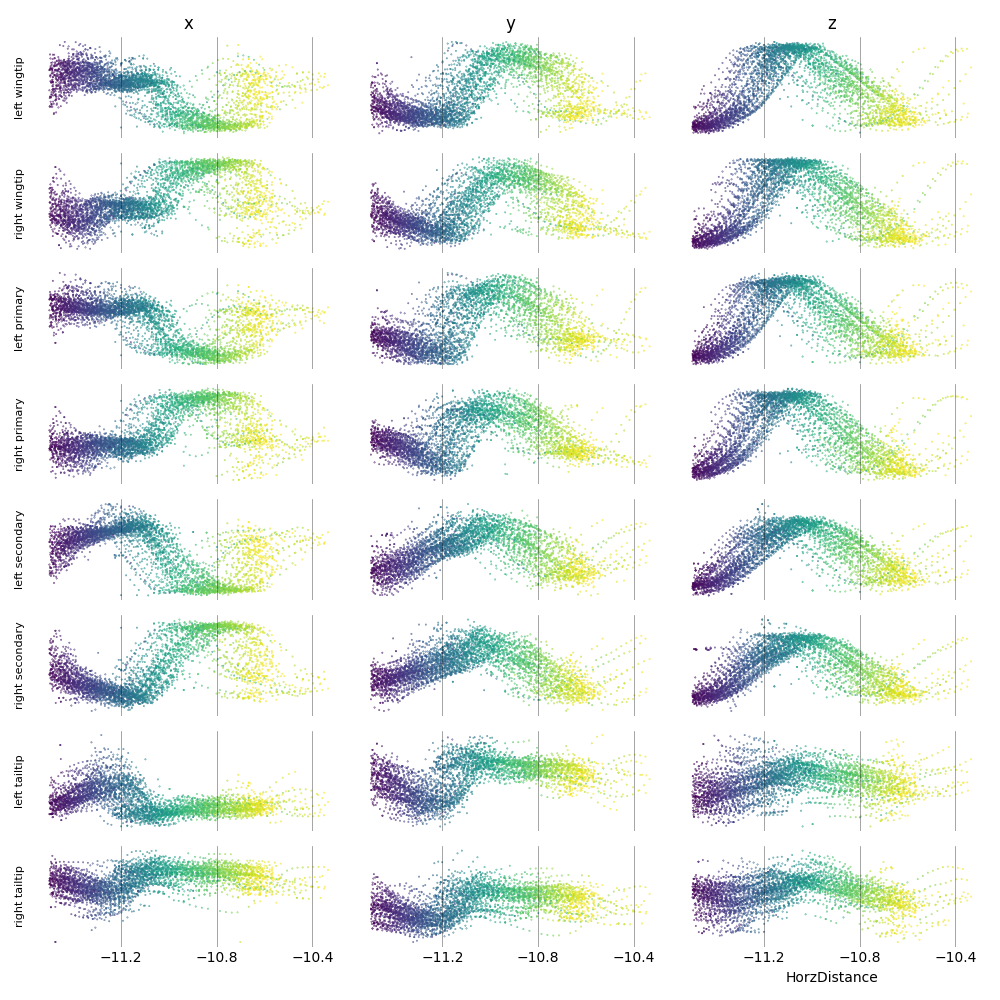

In [9]:
plot_markers_overDist(wingbeat_df, marker_column_names, x_axis='HorzDistance')

# Plot the Marker Trajectories in 2d

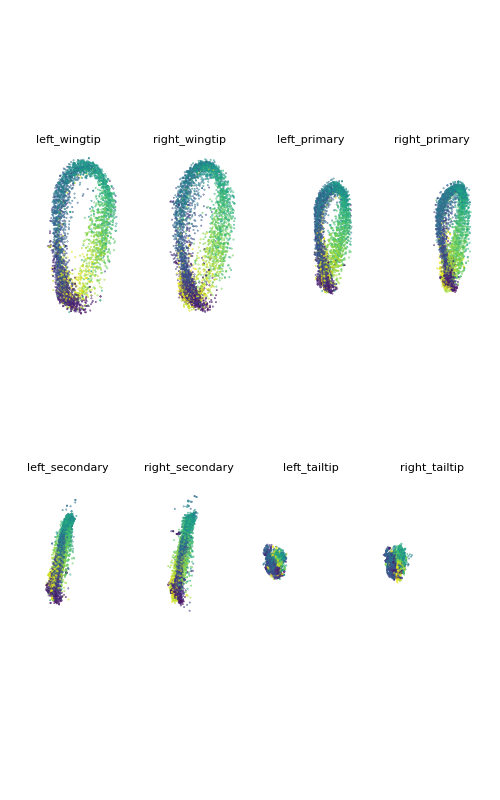

In [10]:
plot_2d_markers(wingbeat_df, marker_column_names)

## Find Sequence Lengths

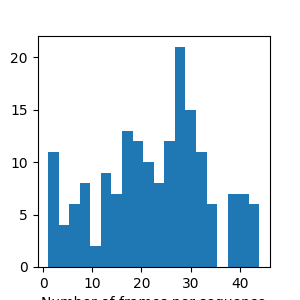

In [5]:
# Using seqID as a category, find the number of rows in each category
seqID_counts = wingbeat_df['seqID'].value_counts()

# Create a histogram
plt.figure(figsize=(3,3))
plt.hist(seqID_counts, bins=20)
plt.xlabel("Number of frames per sequence")

plt.show()

## Plot a Single Sequence

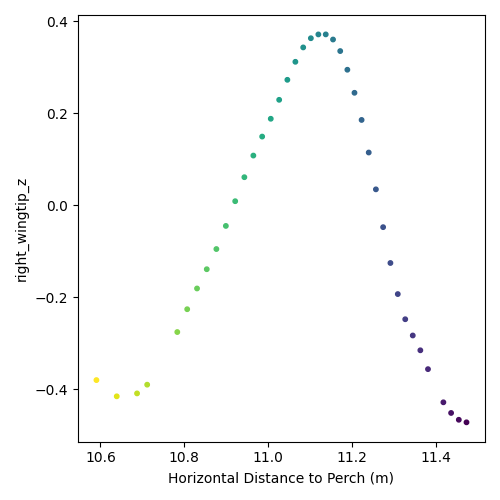

In [6]:

plot_single_sequence(wingbeat_df, 2, marker_name="right_wingtip_z")

## Remove Duplicated Time Frames

In [7]:
duplicates = wingbeat_df[wingbeat_df.duplicated(subset=['frameID'], keep=False)]

ratio_duplicates = (duplicates.shape[0]/wingbeat_df.shape[0])*100
print(f"Duplicated frames are {np.round(ratio_duplicates,2)}% of the total data. ")


# Remove duplicates
wingbeat_df = wingbeat_df.drop_duplicates(subset=['frameID'], keep='first')

# Remember to reset the index
wingbeat_df = wingbeat_df.reset_index(drop=True)

Duplicated frames are 10.13% of the total data. 


# DMD on Single Flight

/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


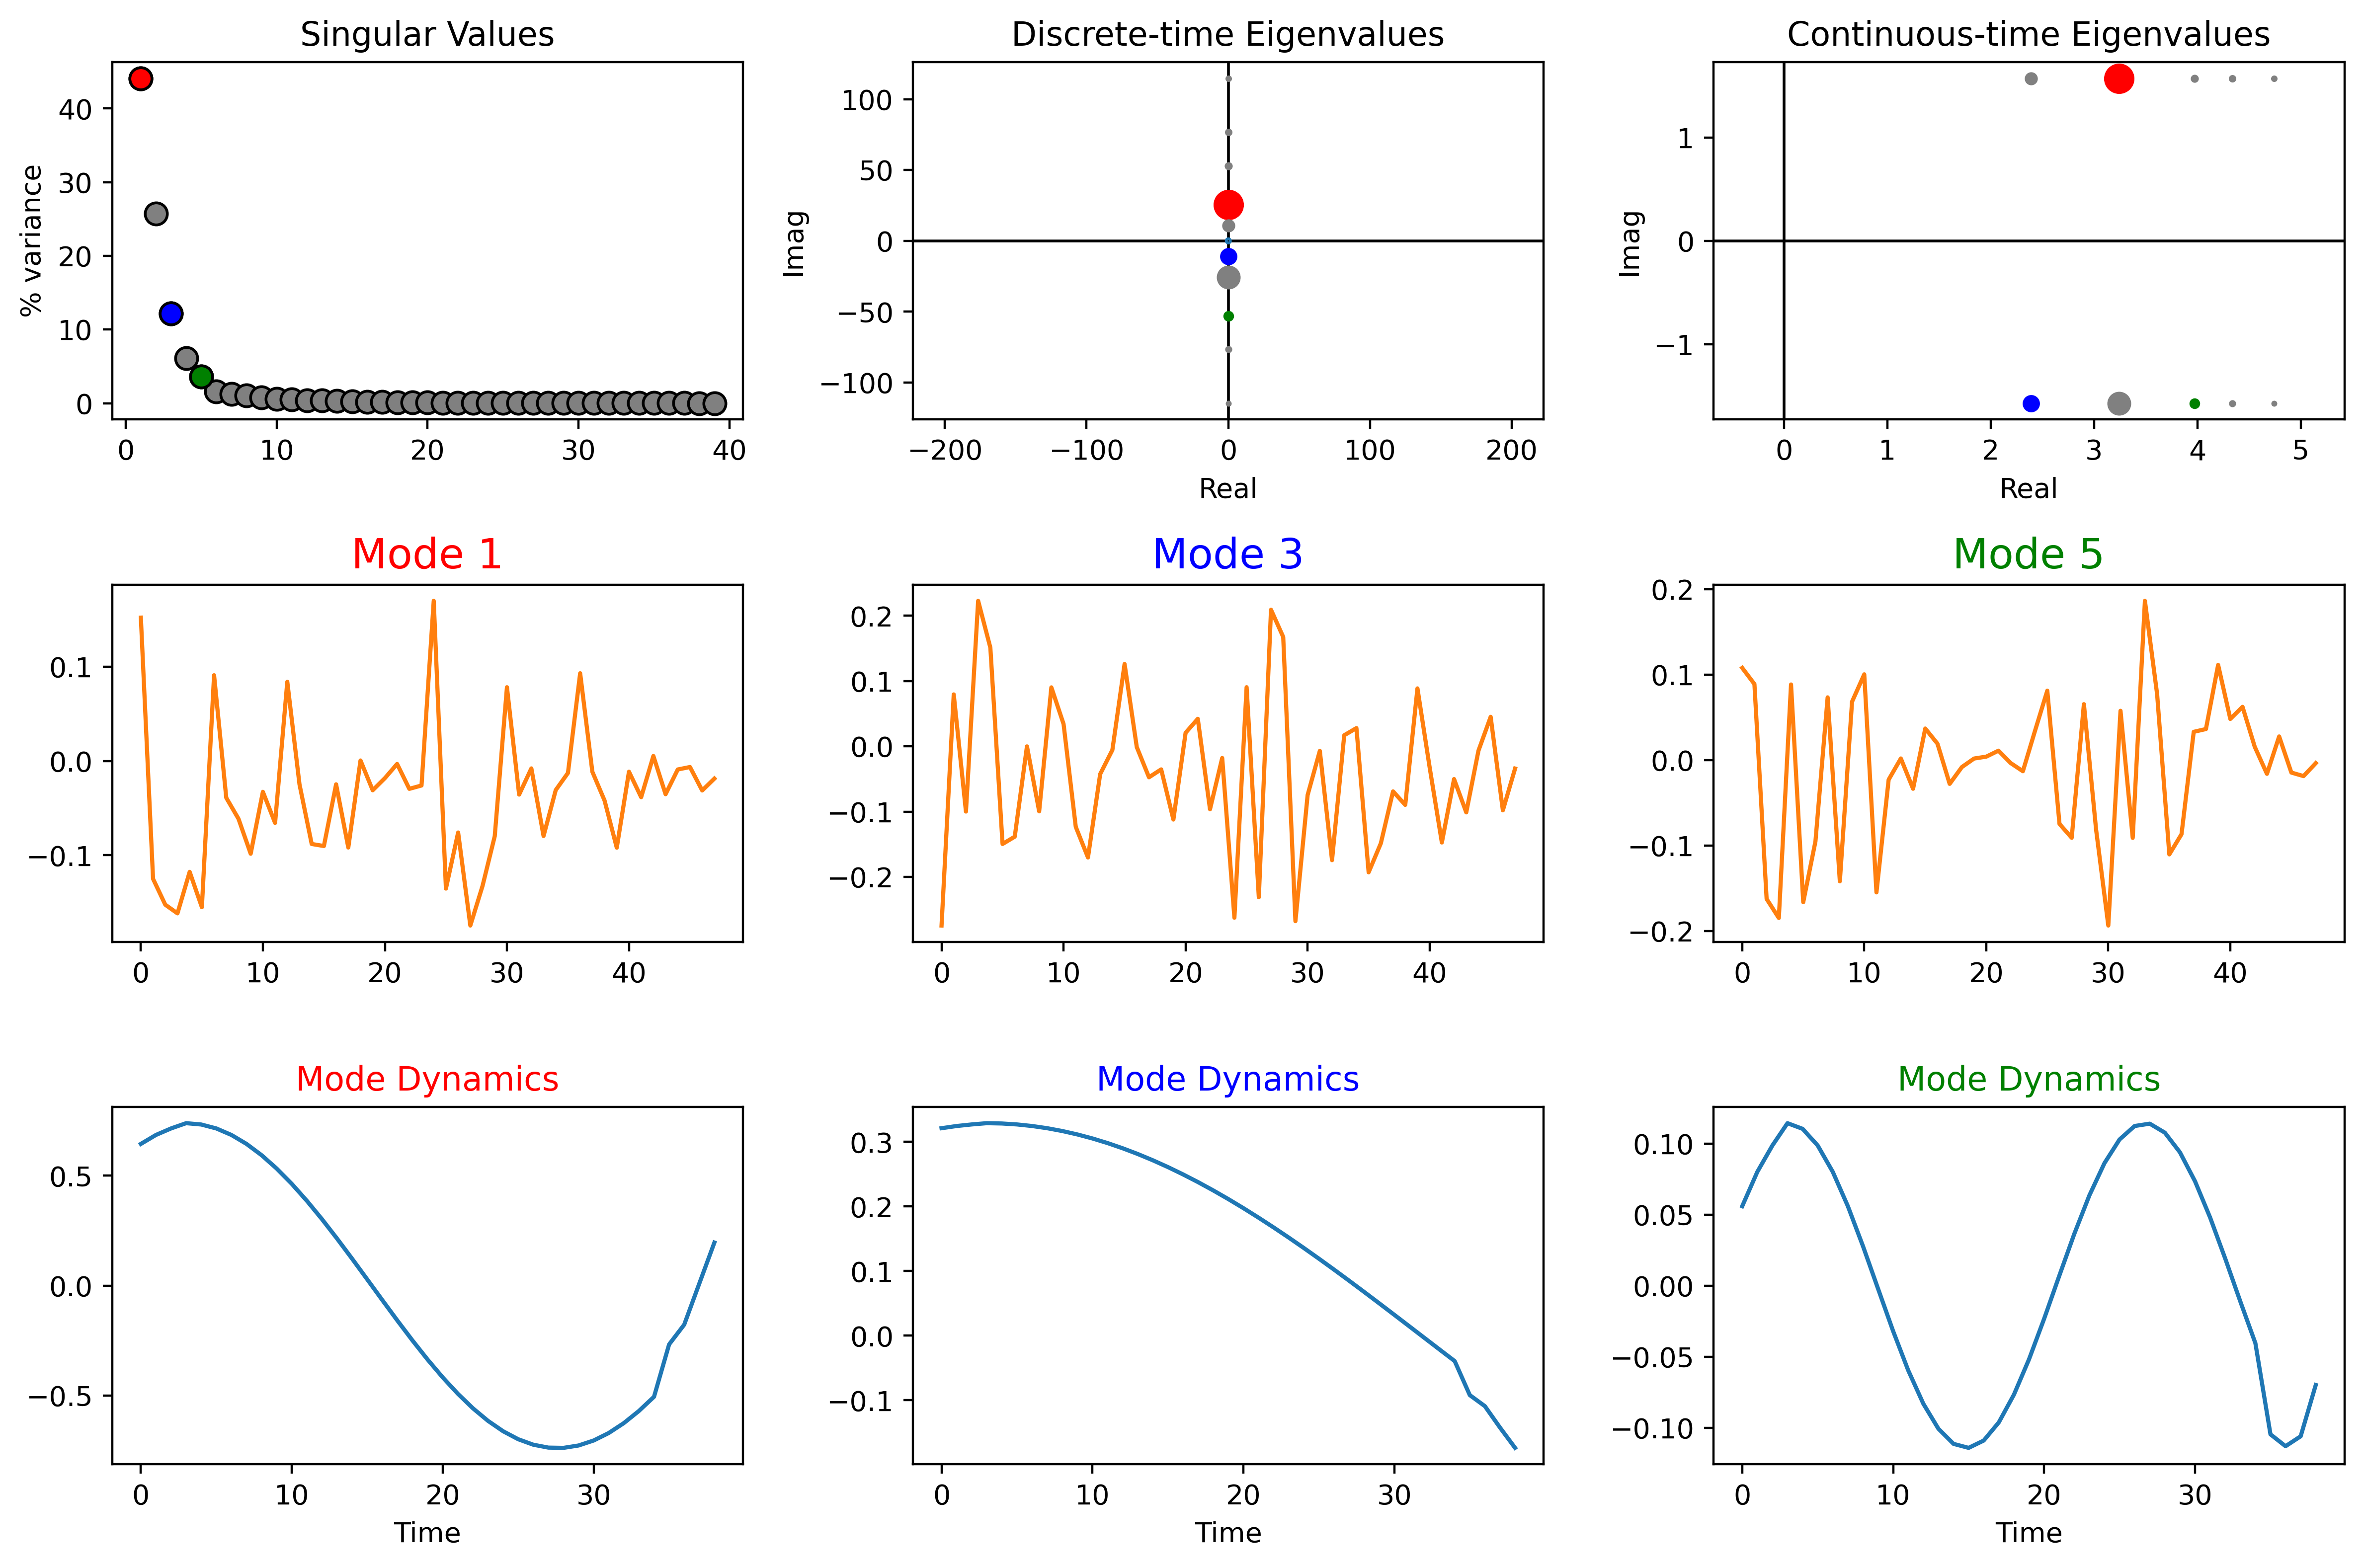

In [31]:
%matplotlib inline
%matplotlib inline


def load_sequence_data(wingbeat_df, seqID, marker_column_names):
    """Load markers and time data for a given sequence ID."""
    condition = wingbeat_df['seqID'] == seqID
    single_seq_markers = wingbeat_df[condition][marker_column_names].to_numpy().astype(np.float64)
    single_seq_time = wingbeat_df[condition]['time'].to_numpy().astype(np.float64)
    return single_seq_markers, single_seq_time

def normalise_data(markers):
    """Normalize marker data by subtracting the average shape."""

    hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
    average_shape = hawk3d.markers.reshape(24,1).T

    return markers - average_shape, average_shape

def transpose_data(data):
    """Transpose the given data."""
    return data.T

def add_average_shape(data, average_shape):
    """Add the average shape back to the data."""
    return data + average_shape

def reshape_data(data, rows, cols, depth):
    """Reshape data to the specified dimensions."""
    return data.reshape(rows, cols, depth)


# Load and process a single sequence
seqList = wingbeat_df['seqID'].unique()
seqID = seqList[2]
markers, times = load_sequence_data(wingbeat_df, seqID, marker_column_names)

# Normalise the data using a class instance to handle the hawk shape
normalised_markers, average_shape = normalise_data(markers)
transposed_markers = transpose_data(normalised_markers)

# Dynamic Mode Decomposition (DMD)
n_Modes = 10
delay_optdmd = hankel_preprocessing(BOPDMD(svd_rank=n_Modes, eig_constraints={"imag", "conjugate_pairs"}), d=2)
delay_optdmd.fit(transposed_markers, t=times[1:])


plot_summary(delay_optdmd, index_modes=[0,2,4], order='F') # pick correct modes


## Compare Original Flight and DMD Reconstruction

Figure and axes initialized.


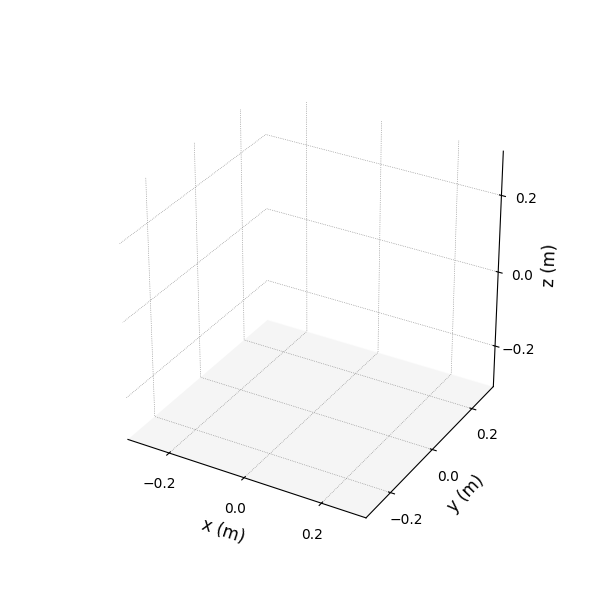

[base_comm.py:246 -             get_comm() ] No such comm: 79bbc1b4ad944480886e7604b0fb3e04


In [32]:
%matplotlib widget
%matplotlib widget

# Forecast the data to recreate the flight with a reduced number of modes
forecast_mean = delay_optdmd.forecast(times)

# Reshape forecast data and add the average shape back
forecast = np.real(forecast_mean[:24,:])
forecast_transposed = transpose_data(forecast)
forecast_plus_mean = add_average_shape(forecast_transposed, average_shape)

# Animate forecast and original in comparison
keypoints = reshape_data(forecast_plus_mean, -1, 8, 3)
# Take away the first frame and add an extra frame to the end
keypoints = np.concatenate([keypoints[1:], keypoints[-1:]], axis=0)

original_markers = reshape_data(markers, -1, 8, 3)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
animate_compare(hawk3d, keypoints_frames_list=[original_markers, keypoints])


# animation.save(f"../figures/gifs/Forecast_{n_Modes}Modes.gif", writer='Pillow', fps=5, dpi=300)
# plt.close("all")


## Process the Results

A reordering step is required to ensure that the modes are ordered by magnitude. 

In [33]:
# Order the results by bn value
bn = delay_optdmd.amplitudes
print(f"Original bn:{bn}")

# Create the index of order
order = np.argsort(bn)[::-1]
print(f"Size order of bn {order}")

# Reorder the results

# Reorder bn
bn = bn[order]
print(f"New bn order: {bn}")

# Reorder Psi
all_Psi = delay_optdmd.modes
Psi = all_Psi[:24,:] # Only take the first 24 modes
Psi = Psi[:,order]

# Reorder Lambda
Lambda = np.imag( delay_optdmd.eigs )
Lambda = Lambda[order]

# Mode Time
ModeTime = delay_optdmd.dynamics
ModeTime = ModeTime[:,order]



Original bn:[0.026 0.026 0.07  0.07  0.114 0.114 0.739 0.739 0.329 0.329]
Size order of bn [6 7 9 8 5 4 2 3 0 1]
New bn order: [0.739 0.739 0.329 0.329 0.114 0.114 0.07  0.07  0.026 0.026]


## Projecting back to the original space

### Step 1: Reconstruct the modes

In [34]:
# all_Psi = delay_optdmd.modes
# Psi = all_Psi[:24,:]

# Lambda = np.imag( delay_optdmd.eigs )

# # Original
Modes = np.real(Psi).reshape((8,3,n_Modes))
Modes_complex = Psi.reshape(8,3,n_Modes)

# Make the 3rd dimension the 1st
Modes = np.moveaxis(Modes, 2, 0)

# Add the average hawk shape back to the mode
# repeat_average = hawk3d.markers.repeat(100, axis=0)


print(Modes.shape)

print(Lambda.shape)

# Dimensions are (11, 100, 8, 3) where:
#        11 is the number of modes
#        100 is the number of time points
#         8 is the number of markers
#         3 is the number of dimensions

DynamicsModes = np.zeros((n_Modes,100, 8,3))
t = times[:]
n = t.shape[0]

for ii in range(n_Modes):
    for jj in range(n):
        DynamicsModes[ii,jj,:,:] = Modes[ii,:,:]*np.cos(Lambda[ii]*t[jj])       
        # DynamicsModes[ii,jj,:,:] = Modes[ii,:,:]*np.sin(Lambda[ii]*t[jj])
        # DynamicsModes[ii,jj,:,:] = Modes_complex[ii,:,:]*np.exp(1j*Lambda[ii]*t[jj])
        # DynamicsModes[ii,jj,:,:] = np.real(Modes_complex[ii,:,:]*np.exp(1j*Lambda[ii]*t[jj]))
        # DynamicsModes[ii,jj,:,:] = Modes_complex[ii,:,:]*np.exp(1j*Lambda[ii]*t[jj]) + Modes_complex[ii+1,:,:]*np.exp(1j*Lambda[ii+1]*t[jj])
        # DynamicsModes[ii,jj,:,:] = bn[ii]*Modes_complex[ii,:,:]*np.exp(1j*Lambda[ii]*t[jj]) + bn[ii+1]*Modes_complex[ii+1,:,:]*np.exp(1j*Lambda[ii+1]*t[jj])





print(DynamicsModes.shape)



(10, 8, 3)
(10,)
(10, 100, 8, 3)


In [35]:

%matplotlib widget
%matplotlib widget

# Shortening the frames down to the first 50, also 
# for now only taking the right markers for the animation
# right_dynamicsMode = DynamicsModes[1,0:50,1::2,:].copy()

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
for mode in range(n_Modes):
    dynamics_mode = (DynamicsModes[mode,0:50,:,:]*bn[mode])+hawk3d.markers.repeat(50, axis=0)
    animation = animate(hawk3d,dynamics_mode)
    animation.save(f"../figures/gifs/Modes12/DynamicMode{mode+1}.gif", writer='Pillow', fps=5, dpi=300)
    plt.close("all")

# dynamics_mode_1 =(DynamicsModes[2,0:50,:,:]*0.5)+hawk3d.markers.repeat(50, axis=0)

# # Add back to the average shape (right side only here, for now the animation code will mirror the left)
# # right_dynamicsMode = (right_dynamicsMode)+hawk3d.right_markers.repeat(50, axis=0)
    
# animation = animate(hawk3d,dynamics_mode_1)
# animation.save(f"../figures/gifs/DynamicMode1st.gif", writer='Pillow', fps=5, dpi=300)


[animation.py:1057 -                 save() ] MovieWriter Pillow unavailable; using Pillow instead.


Figure and axes initialized.


[animation.py:1057 -                 save() ] MovieWriter Pillow unavailable; using Pillow instead.


Figure and axes initialized.


[animation.py:1057 -                 save() ] MovieWriter Pillow unavailable; using Pillow instead.


...

Figure and axes initialized.


[animation.py:1057 -                 save() ] MovieWriter Pillow unavailable; using Pillow instead.


Figure and axes initialized.


[animation.py:1057 -                 save() ] MovieWriter Pillow unavailable; using Pillow instead.


Figure and axes initialized.
